In [1]:
import argparse
import os
import time

import PIL
from PIL import Image

import numpy as np
import torchvision
import pickle
import math
import tqdm
import sklearn

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.autograd import Variable

from sklearn.svm import LinearSVC

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Partie 1 : Architecture VGG16

In [4]:
os.makedirs("data", exist_ok=True)

if os.name == 'nt': # for windows
    !curl -L -o data/imagenet_classes.pkl https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/imagenet_classes.pkl
    !curl -L -o data/cat.jpg "https://unsplash.com/photos/gKXKBY-C-Dk/download?force=true"
    !curl -L -o data/dog.jpg "https://unsplash.com/photos/qO-PIF84Vxg/download?force=true"

else: # not windows
    !wget https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/imagenet_classes.pkl -O data/imagenet_classes.pkl

    # Bonus : Classifiez des exemples avec vgg16 et commentez le résultat dans votre rapport.
    !wget --content-disposition https://unsplash.com/photos/gKXKBY-C-Dk/download?force=true -O data/cat.jpg
    !wget --content-disposition https://unsplash.com/photos/qO-PIF84Vxg/download?force=true -O data/dog.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 35454  100 35454    0     0  62760      0 --:--:-- --:--:-- --:--:-- 1049k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100 1970k  100 1970k    0     0  4158k      0 --:--:-- --:--:-- --:--:-- 4158k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..1.7162529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.3785625].


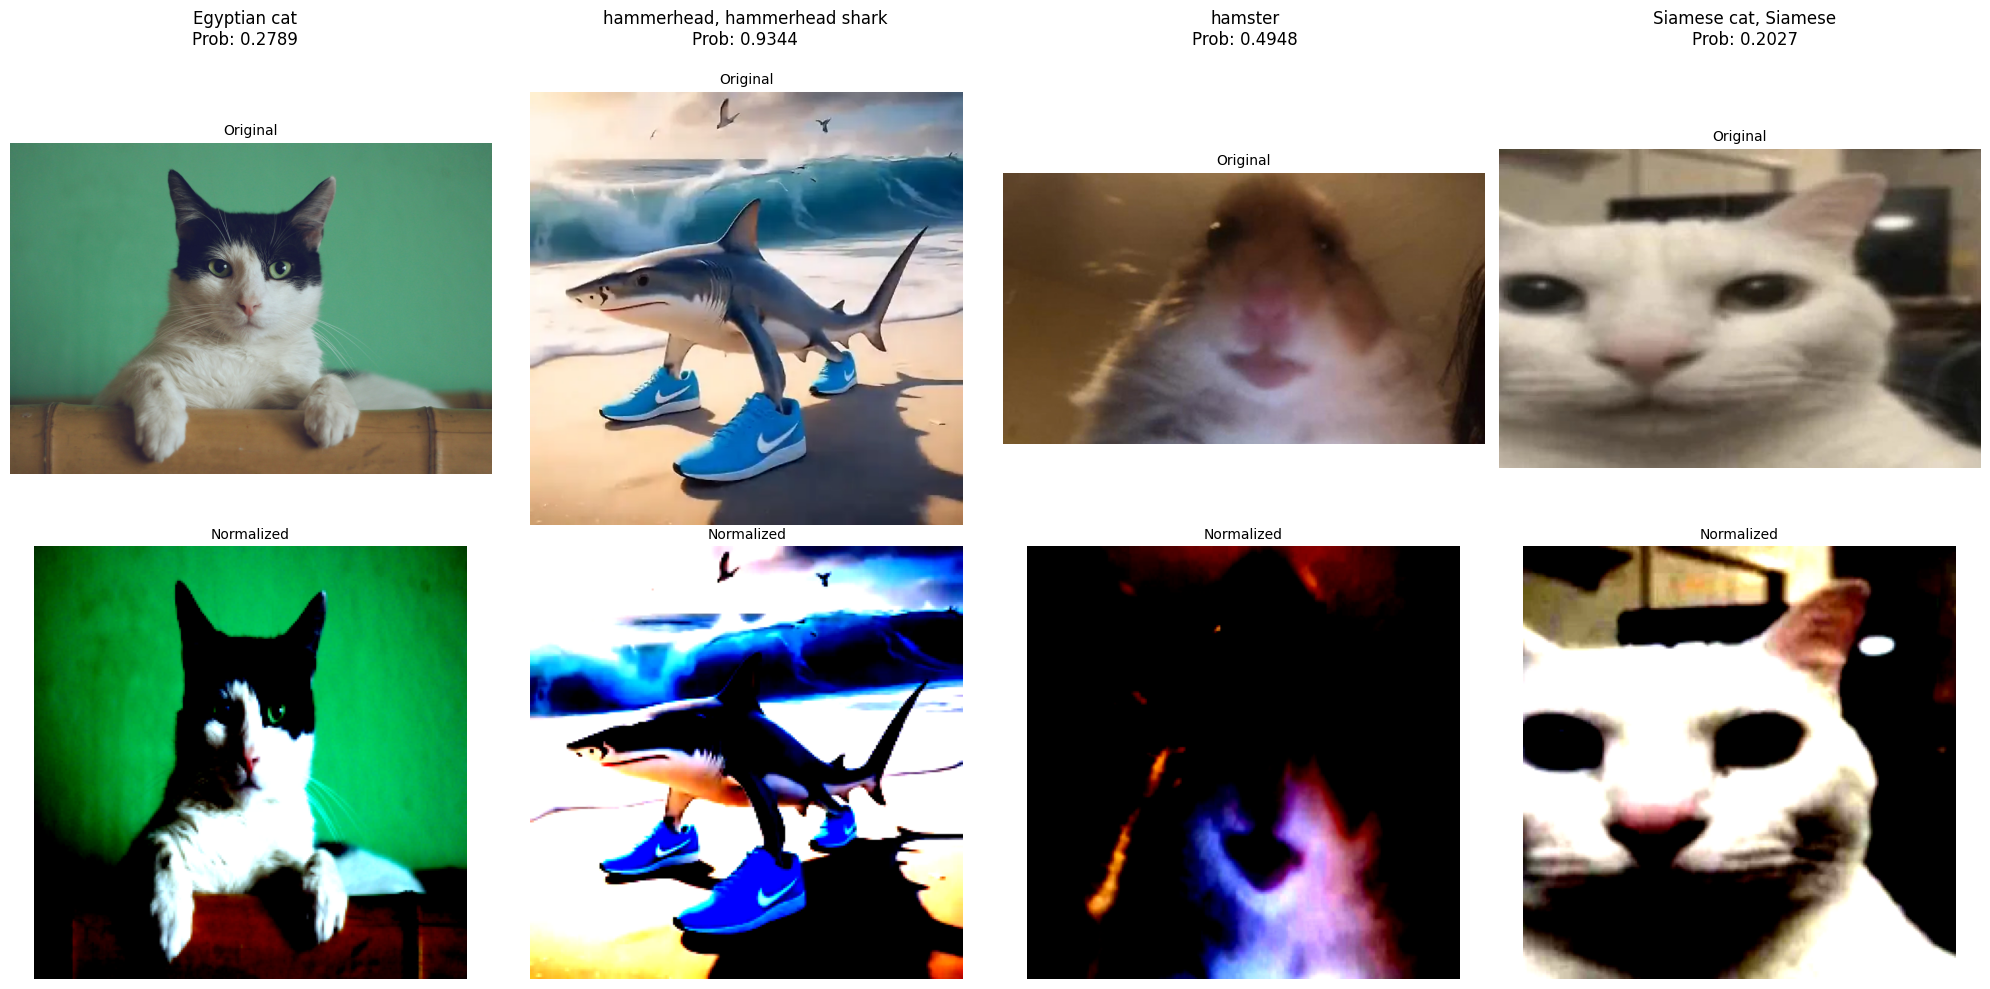

In [3]:
#cat = Image.open('cat.jpg')
cat_img = Image.open('data/cat.jpg')
dog_img = Image.open('data/dog.jpg')
hamster_img = Image.open('data/hamster.jpg')
cat2_img = Image.open('data/cat2.jpg')
shark_img = Image.open('data/shark.png')

# Loading ImageNet classes
imagenet_classes = pickle.load(open('data/imagenet_classes.pkl', 'rb'))

def normalize_image(img):
    # Normalization
    img = img.resize((224, 224), Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255
    img = img.transpose((2, 0, 1))
    # ImageNet mean/std
    mu = torch.Tensor([0.485, 0.456, 0.406])
    sigma = torch.Tensor([0.229, 0.224, 0.225])
    # Expand mu & sigma to match image size

    mu = mu[:, None, None]
    sigma = sigma[:, None, None] 
    # now its of size (3, 1, 1)

    # compute the normalized image with mean ImageNet image
    img = (torch.Tensor(img) - mu) / sigma

    return img

def predict_label(img, model, classes_list):
    # Forward pass on VGG
    img = np.expand_dims(img, 0)
    x = torch.Tensor(img)
    y = model(x)
    y = y.detach().numpy() # transformation en array numpy

    prob = torch.softmax(torch.tensor(y), dim=1).numpy()
    # Get prediction (i.e., ImageNet class label)
    pred_id = np.argmax(y)
    pred_label = classes_list[pred_id]
    pred_prob = prob[0, pred_id]
    return pred_prob, pred_id, pred_label

def multiplot_images_with_predictions(images, model, classes_list):
    n = len(images)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 10))  # 2 rows: original + normalized
    for i, img in enumerate(images):
        norm_img = normalize_image(img)
        pred_prob, pred_id, pred_label = predict_label(norm_img, model, classes_list)
        title_text = f"{pred_label}\nProb: {pred_prob:.4f}"

        fig.text((i + 0.5)/n, 0.95, title_text, ha='center', fontsize=12)
        # og image
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        axes[0, i].set_title("Original", fontsize=10)

        # normalized image
        norm_img_display = norm_img.permute(1, 2, 0).numpy()
        axes[1, i].imshow(norm_img_display)
        axes[1, i].axis('off')
        axes[1, i].set_title("Normalized", fontsize=10)

        

    plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for fig.text at top
    plt.show()
    

# Loding pre-trained VGG
# we are not using vgg16 = torchvision.models.vgg16(pretrained=True)
# because it is deprecated (and i we dont want to see the warning signals)
vgg16 = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1) # only version available i think
vgg16.eval() # WHY THAT ? bc we are not trying to train the model (inference only)

images = [cat_img, shark_img, hamster_img, cat2_img]

multiplot_images_with_predictions(images, vgg16, imagenet_classes)

Bonus question on activation maps:

In [4]:

def get_layer_activation(model, image):
    x = image.unsqueeze(0)  # add batch dimension
    with torch.no_grad():
        activation_map = model.features[0](x)  # first layer
    return activation_map.squeeze(0)  # remove batch dimension

def plot_activation_maps(activation, nmaps=None):
    n_maps = activation.size(0) if nmaps is None else nmaps # to avoid printing all of them if specified
    n_cols = 8 # 8 images per col
    n_rows = math.ceil(n_maps / n_cols)

    # plot maps
    plt.figure(figsize=(n_cols*2, n_rows*2))
    for i in range(n_maps):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(activation[i].numpy(), cmap='viridis')
        plt.axis('off')
        plt.title(f'{i+1}', fontsize=8)
    plt.suptitle("First conv layer activations", fontsize=14)
    plt.tight_layout()
    plt.show()

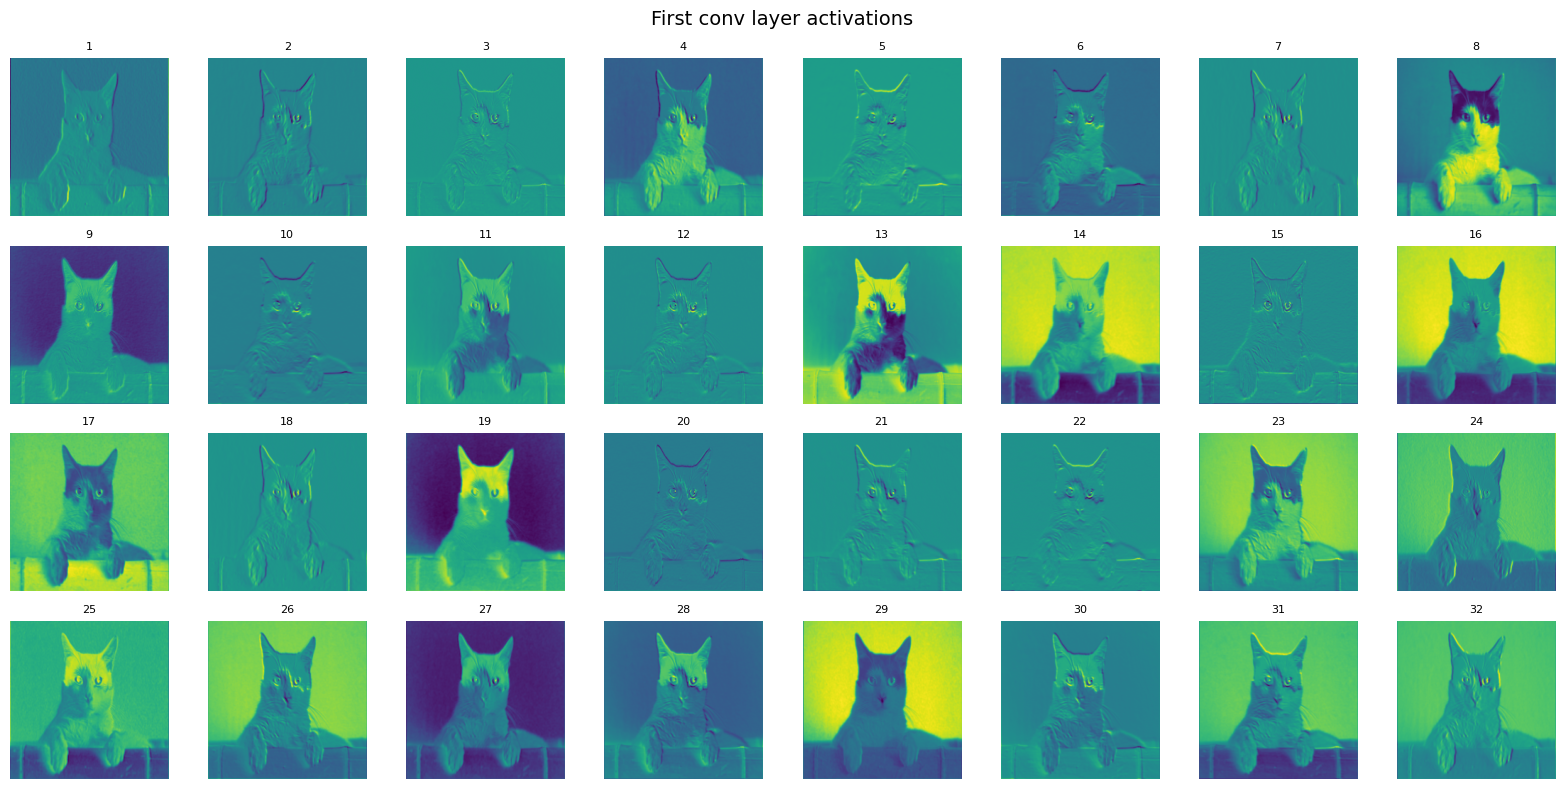

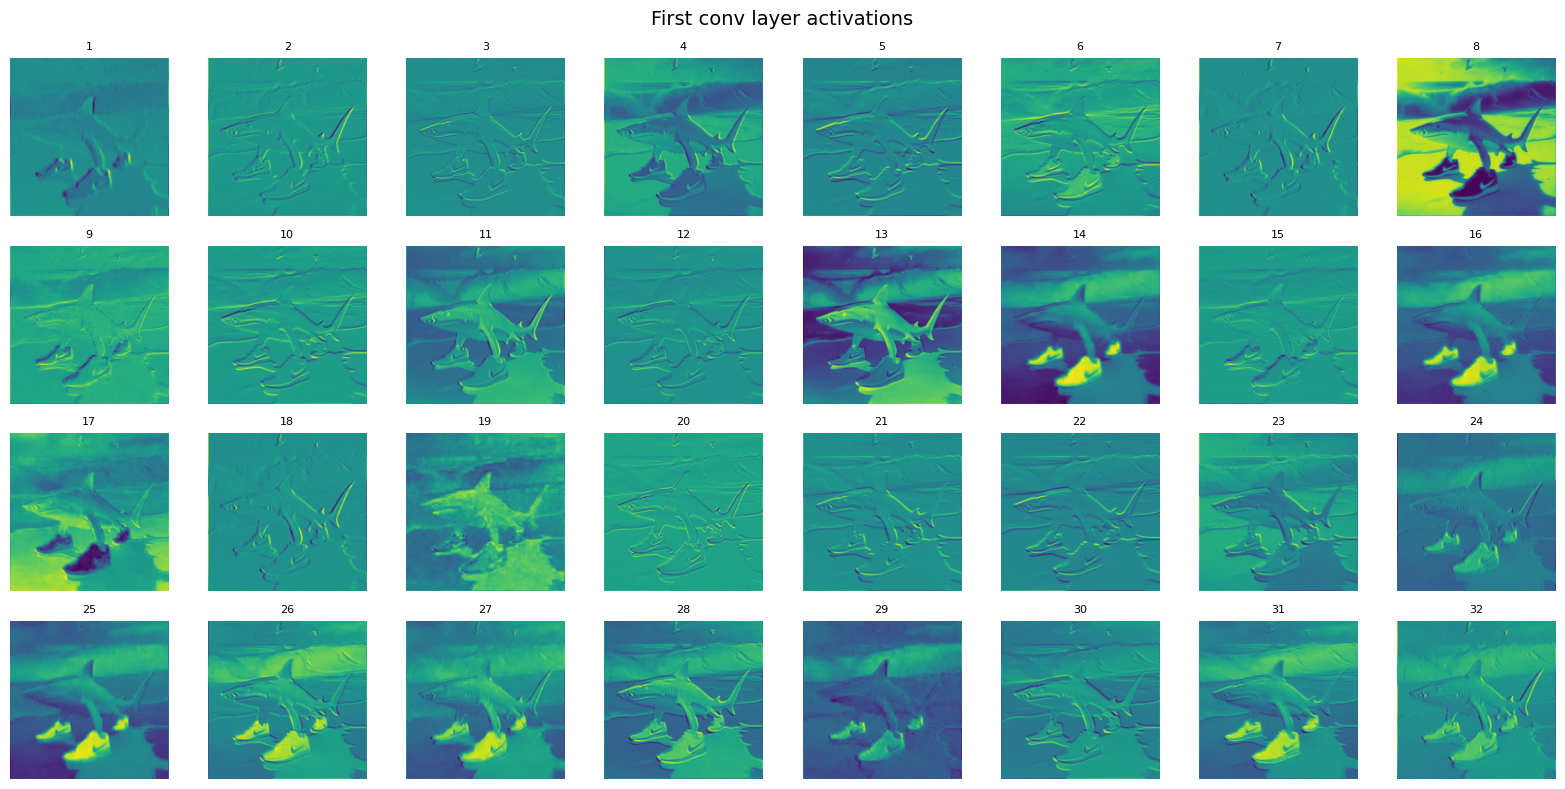

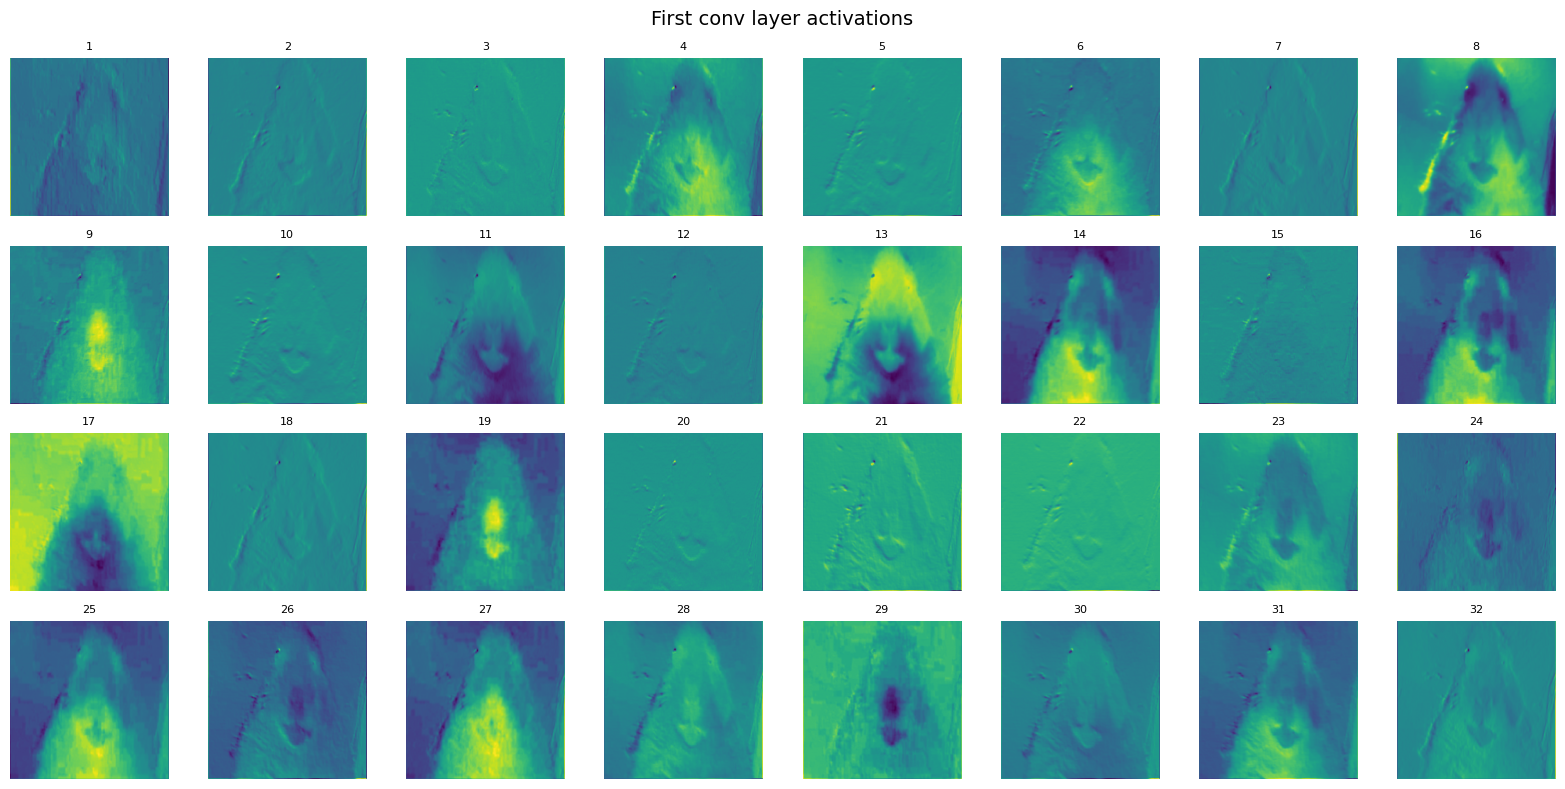

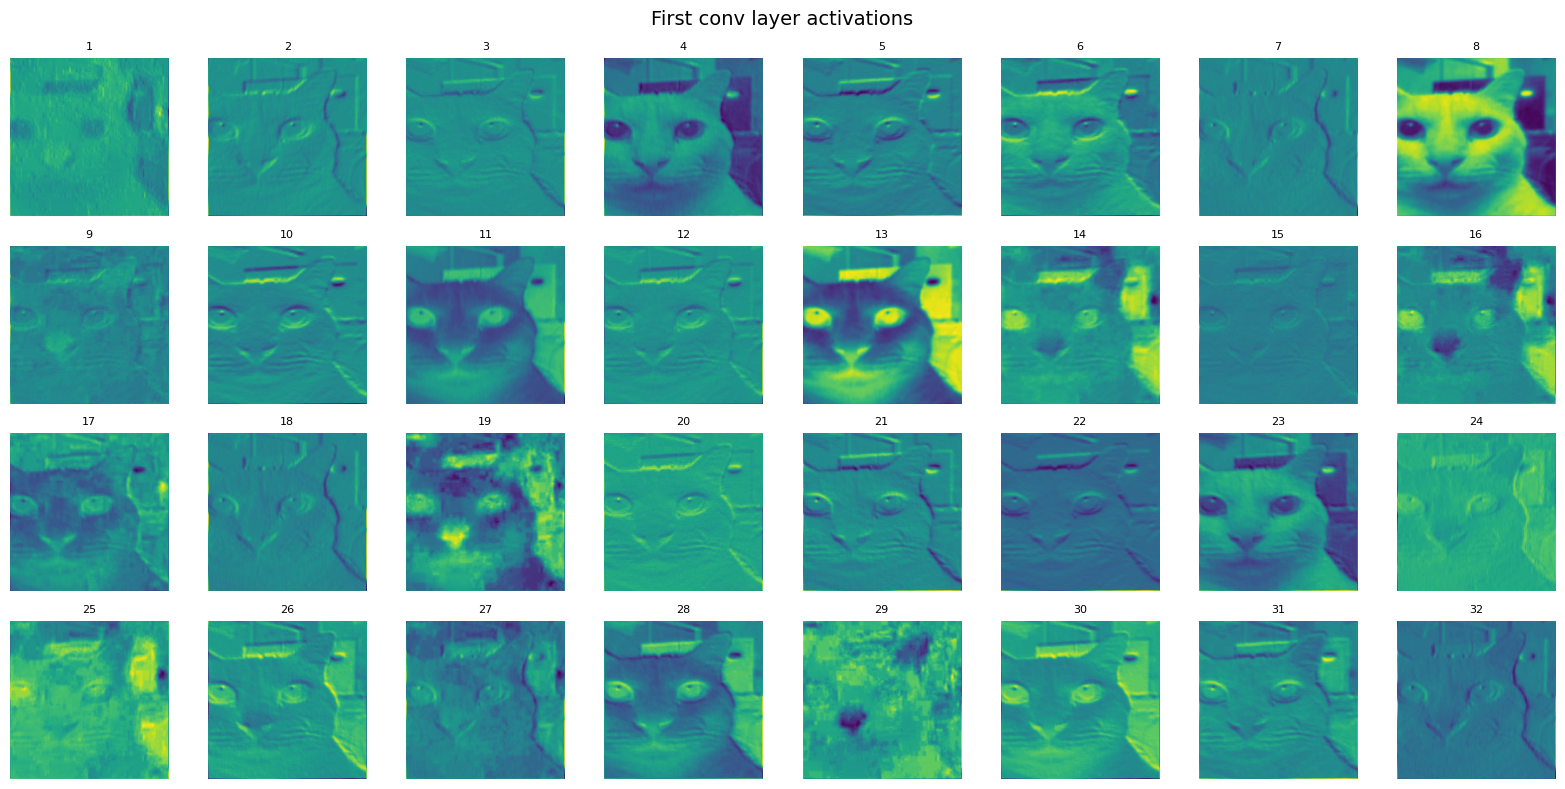

In [5]:
for img in images:
    norm_img = normalize_image(img)
    act = get_layer_activation(vgg16, norm_img)
    plot_activation_maps(act, nmaps=32)

# Partie 2: Transfer Learning avec VGG16 sur 15 Scene

In [8]:
if os.name == 'nt': # for windows
    !curl -L -o data/15ScenesData.zip https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/15ScenesData.zip 

else:
    !wget -O data/15ScenesData.zip https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/15ScenesData.zip 
    !unzip data/15ScenesData.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0

  0     0    0     0    0     0      0      0 --:--:--  0:00:03 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:04 --:--:--     0
  0 82.5M    0  9646    0     0   1918      0 12:31:49  0:00:05 12:31:44  6452
 17 82.5M   17 14.1M    0     0  2588k      0  0:00:32  0:00:05  0:00:27 6972k
 47 82.5M   47 39.2M    0     0  6073k      0  0:00:13  0:00:06  0:00:07 12.7M
 79 82.5M   79 65.4M    0     0  8803k      0  0:00:09  0:00:07  0:00:02 16.0M
100 82.5M  100 82.5M    0     0   9.9M      0  0:0

Make sure you unzip it yourself if you are running this on windows before proceeding

In [6]:
print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [7]:
class VGG16relu7(nn.Module):
    def __init__(self, vgg16, n_layer=2):
      super(VGG16relu7, self).__init__()
      self.features = nn.Sequential( *list(vgg16.features.children()))
      self.classifier = nn.Sequential(*list(vgg16.classifier.children())[:-n_layer])
      
    def forward(self, x):
      x = self.features(x)
      x = x.view(x.size(0), -1)
      x = self.classifier(x)
      return x

In [8]:

PRINT_INTERVAL = 50
CUDA = True

def duplicateChannel(img):
        img = img.convert('L')
        np_img = np.array(img, dtype=np.uint8)
        np_img = np.dstack([np_img, np_img, np_img])
        img = Image.fromarray(np_img, 'RGB')
        return img

def resizeImage(img):
      return img.resize((224,224), Image.BILINEAR)

def get_dataset(batch_size, path):
    train_dataset = datasets.ImageFolder(path+'/train',
        transform=transforms.Compose([
                    transforms.Resize((224, 224), interpolation=Image.BILINEAR),
                    transforms.Lambda(duplicateChannel),
                    transforms.ToTensor(),
                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    )
    val_dataset = datasets.ImageFolder(path+'/test',
        transform=transforms.Compose([
                    transforms.Resize((224, 224), interpolation=Image.BILINEAR),
                    transforms.Lambda(duplicateChannel),
                    transforms.ToTensor(),
                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    )

    train_loader = torch.utils.data.DataLoader(train_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=CUDA, num_workers=0)
    val_loader = torch.utils.data.DataLoader(val_dataset,
                        batch_size=batch_size, shuffle=False, pin_memory=CUDA, num_workers=0)

    return train_loader, val_loader

Let's do a little test to see if the dataset loader works:

C:\Users\titou\AppData\Local\Temp\ipykernel_11360\2196152119.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Number of training samples: 1500


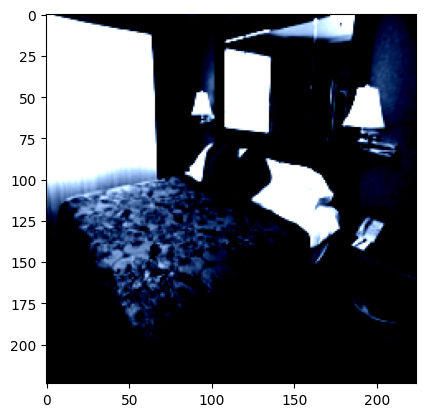

In [9]:
train_loader, val_loader = get_dataset(batch_size=32, path='data/15SceneData')

print("Number of training samples:", len(train_loader.dataset))
# display a sample of that data:
# note that this image went through the normalization process so it looks a bit goofy
plt.imshow(train_loader.dataset[0][0].permute(1, 2, 0).numpy()) # permute to get the proper shape 

In [10]:
def extract_features(data, model):
    X_list = []
    y_list = []

    # here we are not storing everything on the GPU to avoid memory issues
    # bc whne i had torch tensors then the .cat would consume all the memory
    # so use lists on cpu and then convert back to tensors to put on gpu later
    for input, target in tqdm.tqdm(data, total=len(data), unit="batch"):
        input = input.to(device)
        with torch.no_grad():
            feats = model(input).cpu()  
        X_list.append(feats)
        y_list.append(target)

    X = torch.cat(X_list)
    y = torch.cat(y_list)
    return X, y


def main(path="15SceneData", batch_size=8, new_model=VGG16relu7, n_layers=2):
    print('Instanciation de VGG16')
    vgg16 = models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1) # updated way to call it

    print('Instanciation de VGG16relu7')
    # just the model that we pass (model)

    # Remplacer par le modèle par un réseau tronqué pour faire de la feature extraction
    # On créera une nouvelle classe VGG16relu7 ici
    model = new_model(vgg16, n_layer=n_layers) # here model is the class VGG16relu7

    model.eval()
    model.to(device)

    # On récupère les données
    print('Récupération des données')
    train, test = get_dataset(batch_size, path)

    # Extraction des features
    print('Feature extraction')
    X_train, y_train = extract_features(train, model)
    X_test, y_test = extract_features(test, model)

    # Apprentissage et évaluation des SVM à faire
    print('Apprentissage des SVM')
    accuracy = 0

    svm = LinearSVC(C=1.0, max_iter=100000).fit(X_train, y_train) # if we do 'only' 10000 it doenst converge so i did x10 again and now it converged (acc satyed the same tho)
    y_hat = svm.predict(X_test)
    accuracy = sklearn.metrics.accuracy_score(y_test.cpu(), y_hat)

    print('Accuracy = %f' % accuracy)


In [18]:
torch.cuda.empty_cache()
main("data/15SceneData", 8)

Instanciation de VGG16
Instanciation de VGG16relu7
Récupération des données
Feature extraction


  0%|          | 0/188 [00:00<?, ?batch/s]C:\Users\titou\AppData\Local\Temp\ipykernel_18000\2196152119.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
100%|██████████| 374/374 [00:28<00:00, 13.34batch/s]


Apprentissage des SVM
Accuracy = 0.885762


**Going further**

Once this classification sceme works, you can study the effect of two (or more) choices on the performances
or training time. Some possible examples are listed below but you are free to find others!

* Change the layer at which the features are extracted. What is the importance of the depth of this
layer? What is the representation size and what does this change?

* Try other available pre-trained networks. What are the differences between these networks?

* Tune the parameter C to improve performance.

* Instead of training an SVM, replace the last layer of VGG16 with a new fully-connected layer and
continue to train the network on 15 Scene (with or without propogating the gradients to the rest of
the network).

* Look into methods for dimensionality reduction before classification and their impact on performance
and execution time.

**Change the layer at which the features are extracted**

In [11]:
# Change the layer at which the features are extracted. What is the importance of the depth of this
# layer? What is the representation size and what does this change?
# recap of VGG16 architecture:

print(vgg16)

# so before we removed the last two now we remove the last 5

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [20]:
torch.cuda.empty_cache()
main("data/15SceneData", 8, VGG16relu7, n_layers=5)

Instanciation de VGG16
Instanciation de VGG16relu7
Récupération des données
Feature extraction


  0%|          | 0/188 [00:00<?, ?batch/s]C:\Users\titou\AppData\Local\Temp\ipykernel_18000\2196152119.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
100%|██████████| 374/374 [00:17<00:00, 21.29batch/s]


Apprentissage des SVM
Accuracy = 0.901508


**Tune the parameter C to improve performance**

In [13]:
# Tune the parameter C to improve performance.
# we can use a grid search 
from sklearn.model_selection import GridSearchCV

svm = LinearSVC(dual="auto", max_iter=10000)

grid_search = GridSearchCV(svm, {"C": [0.5, 1, 10, 100]}, n_jobs=2)

train, test = get_dataset(8, "data/15SceneData")
X_train, y_train = extract_features(train, VGG16relu7(vgg16, n_layer=5).to(device)) #use 5 cuz it seemed better 

grid_search.fit(X_train, y_train)

print("best params:", grid_search.best_params_)
print("best cross-val score:", grid_search.best_score_)

  0%|          | 0/188 [00:00<?, ?batch/s]C:\Users\titou\AppData\Local\Temp\ipykernel_11360\2196152119.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
100%|██████████| 188/188 [00:20<00:00,  9.35batch/s]


best params: {'C': 0.5}
best cross-val score: 0.8826666666666666


In [14]:
accuracy = 0
svm = grid_search.best_estimator_ # thats our svm

X_test, y_test = extract_features(test, VGG16relu7(vgg16, n_layer=5).to(device))

y_hat = svm.predict(X_test)
accuracy = sklearn.metrics.accuracy_score(y_test.cpu(), y_hat)

print('Accuracy = %f' % accuracy)


  0%|          | 0/374 [00:00<?, ?batch/s]C:\Users\titou\AppData\Local\Temp\ipykernel_11360\2196152119.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
100%|██████████| 374/374 [00:39<00:00,  9.43batch/s]


Accuracy = 0.901508


Im getting the exact same accuracy on test to the decimal close??? Maybe investiagte that idk

**Try other available pre-trained networks**

In [23]:
# we can use ResNet50 or InceptionV3, we will test both for classification on teh dataset

resnet50 = models.resnet50(pretrained=True)

inceptionv3 = models.inception_v3(pretrained=True)

d:\Sorbonne\M2-MIND\RDFIA\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Sorbonne\M2-MIND\RDFIA\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
d:\Sorbonne\M2-MIND\RDFIA\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAU

In [32]:
class ResNet50Features(nn.Module):
    def __init__(self, n_layer=None):
        super().__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        # Remove the final fc layer
        self.features = nn.Sequential(*list(self.resnet.children())[:-1])  # everything except fc

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # flatten to (batch_size, 2048)
        return x

In [ ]:
def main_resnet(path="data/15SceneData", batch_size=8):
    print("init of ResNet50Features")
    model = ResNet50Features()
    model.eval()
    model.to(device)

    # Load dataset
    train_loader, val_loader = get_dataset(batch_size, path)

    # Extract features
    print("Extraction des features...")
    X_train, y_train = extract_features(train_loader, model)
    X_test, y_test = extract_features(val_loader, model)

    # Train SVM
    print("Apprentissage du SVM...")

    svm = LinearSVC(C=1.0, max_iter=100000)
    svm.fit(X_train, y_train)
    y_hat = svm.predict(X_test)
    accuracy = sklearn.metrics.accuracy_score(y_test, y_hat)

    print(f"Accuracy = {accuracy:.4f}")

In [37]:
main_resnet()

Instanciation de ResNet50Features
Extraction des features...


  0%|          | 0/188 [00:00<?, ?batch/s]C:\Users\titou\AppData\Local\Temp\ipykernel_11360\2196152119.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
100%|██████████| 374/374 [00:11<00:00, 33.48batch/s]


Apprentissage du SVM...
Accuracy = 0.9085


Ok lets do the same for InceptionV3!

In [53]:
class InceptionV3Features(nn.Module):
    def __init__(self):
        super().__init__()
        # pretrained inception, ignore aux_logits
        self.inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        self.inception.fc = nn.Identity()  # replace fc with identity

    def forward(self, x):
        x = self.inception(x)  # now output is 2048-dim feature vector
        return x


In [48]:
def get_dataset_inception(batch_size, path):
    transform = transforms.Compose([
        transforms.Resize((299, 299), interpolation=Image.BILINEAR),
        transforms.Lambda(duplicateChannel),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    
    train_dataset = datasets.ImageFolder(path+'/train', transform=transform)
    val_dataset   = datasets.ImageFolder(path+'/test',  transform=transform)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


In [49]:
def main_inception(path="data/15SceneData", batch_size=8):
    print("Instanciation de InceptionV3Features")
    model = InceptionV3Features()
    model.eval()
    model.to(device)

    # Load dataset
    train_loader, val_loader = get_dataset_inception(batch_size, path)

    # Extract features
    print("Extraction des features...")
    X_train, y_train = extract_features(train_loader, model)
    X_test, y_test   = extract_features(val_loader, model)

    # Train SVM
    from sklearn.svm import LinearSVC
    import sklearn.metrics

    print("Apprentissage du SVM...")
    svm = LinearSVC(C=1.0, max_iter=100000)
    svm.fit(X_train, y_train)
    y_hat = svm.predict(X_test)
    accuracy = sklearn.metrics.accuracy_score(y_test, y_hat)

    print(f"Accuracy = {accuracy:.4f}")

In [54]:
main_inception()

Instanciation de InceptionV3Features
Extraction des features...


  0%|          | 0/188 [00:00<?, ?batch/s]C:\Users\titou\AppData\Local\Temp\ipykernel_11360\2196152119.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(np_img, 'RGB')
100%|██████████| 374/374 [00:14<00:00, 25.69batch/s]


Apprentissage du SVM...
Accuracy = 0.9032


Ok so we can observe that wether we use VGG16, ResNet50 or InceptionV3 we get the same accuracy in test. This could mean that either the limitation comes from the SVM classifier we add at the end, or simply that those models all extract equally good features. We will explore in the next bonus question what happens if we train a FC instead of an SVM. 

Also, here are the difference and main characteristics of the two new models we test:

**ResNet-50**
- uses residual connections, they help to train deeper networks without the vanishing gradient problem

- Deeper than VGG16 (50 layers vs 16) but about the same efficiency


**InceptionV3**

- Uses Inception modules that compute convolutions at multiple scales in parallel

- captures both local and global features very well

- more complex architecture: requires 299×299 input images instead of 224×224.

**Replace the last layer of VGG16 with a new fully-connected layer and continue to train the network on 15 Scene**